In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [31]:
from pathlib import Path

DATA_PATH = Path('Zomato Restaurant Dataset.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'{DATA_PATH} was not found. Place the CSV beside this notebook or update DATA_PATH.')

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', encoding_errors='replace')
df = df_raw.copy()
print(f'Raw rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}')
display(df_raw.head())
display(df_raw.sample(min(5, len(df_raw)), random_state=42))

Raw rows: 9,551 | Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
4731,3918,Wah Ji Wah,1,New Delhi,"B-6/1, Double Story, Near Metro Pillar 371, Ramesh Nagar, Kirti Nagar, New Delhi",Kirti Nagar,"Kirti Nagar, New Delhi",77.128443,28.651778,North Indian,350,Indian Rupees(Rs.),No,No,No,No,1,2.1,Red,Poor,54
1468,18408054,19 Flavours Biryani,1,Gurgaon,"Global Foyer Mall, Sector 43, Golf Course Road, Gurgaon","Global Foyer Mall, Golf Course Road","Global Foyer Mall, Golf Course Road, Gurgaon",77.095432,28.460444,"Mughlai, Hyderabadi",700,Indian Rupees(Rs.),No,Yes,No,No,2,4.1,Green,Very Good,84
9037,309693,Andaaz E Paranthas,1,Noida,"306, 2nd Floor, Food Court, Spice World Mall, Sector 25, Noida","Spice World Mall, Sector 25","Spice World Mall, Sector 25, Noida",77.340449,28.585474,"North Indian, Mughlai",550,Indian Rupees(Rs.),No,No,No,No,2,3.2,Orange,Average,36
7866,18157386,Tony's,1,New Delhi,"C-23, Single Storey, Vijay Nagar, New Delhi",Vijay Nagar,"Vijay Nagar, New Delhi",77.201128,28.692000,Fast Food,200,Indian Rupees(Rs.),No,Yes,No,No,1,4.4,Green,Very Good,163
5570,18396163,Yummy Adda,1,New Delhi,"1333, Near Batra Cinema, Mukherjee Nagar, New Delhi",Mukherjee Nagar,"Mukherjee Nagar, New Delhi",77.216130,28.712062,"North Indian, Mughlai",400,Indian Rupees(Rs.),No,No,No,No,1,3.5,Yellow,Good,14


In [32]:
df = df_raw.copy()
cleaning_summary = {}

# Clean text without guessing at characters lost in the source encoding.
text_columns = df.select_dtypes(include=['object', 'string']).columns
for column in text_columns:
    df[column] = df[column].astype('string').str.strip()
    df[column] = df[column].str.replace('\ufffd', '?', regex=False)
    df[column] = df[column].replace('', pd.NA)

# Normalize binary service fields.
for column in ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']:
    if column in df.columns:
        df[column] = df[column].str.strip().str.title()

# Convert numeric fields; malformed entries become missing and are counted below.
numeric_columns = [
    'Restaurant ID', 'Country Code', 'Longitude', 'Latitude',
    'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes',
]
for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

# Remove exact duplicate records and duplicate IDs, retaining the first occurrence.
exact_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
duplicate_ids = int(df['Restaurant ID'].duplicated().sum()) if 'Restaurant ID' in df.columns else 0
if 'Restaurant ID' in df.columns:
    df = df.drop_duplicates(subset='Restaurant ID', keep='first').copy()

# Fill missing cuisine labels with an explicit category rather than dropping restaurants.
if 'Cuisines' in df.columns:
    missing_cuisines = int(df['Cuisines'].isna().sum())
    df['Cuisines'] = df['Cuisines'].fillna('Unknown')
else:
    missing_cuisines = 0

# Enforce known valid ranges while preserving the rows for EDA and possible scoring.
invalid_counts = {}
if 'Aggregate rating' in df.columns:
    invalid = df['Aggregate rating'].notna() & ~df['Aggregate rating'].between(0, 5)
    invalid_counts['rating_out_of_range'] = int(invalid.sum())
    df.loc[invalid, 'Aggregate rating'] = np.nan
if 'Price range' in df.columns:
    invalid = df['Price range'].notna() & ~df['Price range'].between(1, 4)
    invalid_counts['price_range_out_of_range'] = int(invalid.sum())
    df.loc[invalid, 'Price range'] = np.nan
for column, low, high in [('Longitude', -180, 180), ('Latitude', -90, 90)]:
    if column in df.columns:
        invalid = df[column].notna() & ~df[column].between(low, high)
        invalid_counts[f'{column.lower()}_out_of_range'] = int(invalid.sum())
        df.loc[invalid, column] = np.nan
for column in ['Average Cost for two', 'Votes']:
    if column in df.columns:
        invalid = df[column].notna() & (df[column] < 0)
        invalid_counts[f'{column}_negative'] = int(invalid.sum())
        df.loc[invalid, column] = np.nan

# Keep zero or very large costs visible; mixed currencies and real extremes need context.
if 'Average Cost for two' in df.columns:
    invalid_counts['zero_cost_records'] = int(df['Average Cost for two'].eq(0).sum())
    cost_99 = df['Average Cost for two'].quantile(0.99)
    invalid_counts['cost_above_99th_percentile'] = int(df['Average Cost for two'].gt(cost_99).sum())

cleaning_summary = pd.Series({
    'raw_rows': len(df_raw),
    'clean_rows': len(df),
    'exact_duplicate_rows_removed': exact_duplicates,
    'duplicate_restaurant_ids_removed': duplicate_ids,
    'missing_cuisines_filled_as_Unknown': missing_cuisines,
    **invalid_counts,
    'remaining_missing_cells': int(df.isna().sum().sum()),
})
display(cleaning_summary.rename('count').to_frame())

CLEAN_DATA_PATH = Path('Zomato Restaurant Dataset Cleaned.csv')
df.to_csv(CLEAN_DATA_PATH, index=False, encoding='utf-8-sig')
print(f'Cleaned dataset saved to: {CLEAN_DATA_PATH.resolve()}')
print(f'Cleaned shape: {df.shape}')
display(df.head())

,count
raw_rows,9551
clean_rows,9551
exact_duplicate_rows_removed,0
duplicate_restaurant_ids_removed,0
missing_cuisines_filled_as_Unknown,9
rating_out_of_range,0
price_range_out_of_range,0
longitude_out_of_range,0
latitude_out_of_range,0
Average Cost for two_negative,0


Cleaned dataset saved to: C:\Users\maham\OneDrive\Desktop\Zomato ML Project\Zomato Restaurant Dataset Cleaned.csv
Cleaned shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100.0,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200.0,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000.0,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500.0,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500.0,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


## Data cleaning and validation

Keep `df_raw` as the untouched source copy. The cleaned `df` trims text, marks undecodable text characters clearly, normalizes Yes/No fields, fixes data types, fills missing cuisine labels, and removes exact duplicate rows and repeated restaurant IDs. Invalid ranges become missing values; unusual but plausible costs are retained and flagged rather than removed. The cleaned file is exported for reuse.

In [33]:
df.info()
display(df.describe(include='all').T)

quality = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=True),
    'dtype': df.dtypes.astype(str),
}).sort_values('missing_pct', ascending=False)
display(quality)
print(f'Exact duplicate rows: {df.duplicated().sum():,}')
if 'Restaurant ID' in df.columns:
    print(f'Duplicate restaurant IDs: {df["Restaurant ID"].duplicated().sum():,}')

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   string 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   string 
 4   Address               9551 non-null   string 
 5   Locality              9551 non-null   string 
 6   Locality Verbose      9551 non-null   string 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   string 
 10  Average Cost for two  9551 non-null   float64
 11  Currency              9551 non-null   string 
 12  Has Table booking     9551 non-null   string 
 13  Has Online delivery   9551 non-null   string 
 14  Is delivering now     9551 non-null   string 
 15  Switch to order menu  9551 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,NaN,NaN,NaN,9051128.349178,8791521.282104,53.0,301962.5,6004089.0,18352291.5,18500652.0
Restaurant Name,9551,7446,Cafe Coffee Day,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,9551.0,NaN,NaN,NaN,18.365616,56.750546,1.0,1.0,1.0,1.0,216.0
City,9551,141,New Delhi,5473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,9551,8918,"Dilli Haat, INA, New Delhi",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,9551,1208,Connaught Place,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality Verbose,9551,1265,"Connaught Place, New Delhi",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,9551.0,NaN,NaN,NaN,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,NaN,NaN,NaN,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.97698
Cuisines,9551,1826,North Indian,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_pct,unique_values,dtype
Restaurant ID,0,0.0,9551,int64
Restaurant Name,0,0.0,7446,string
Country Code,0,0.0,15,int64
City,0,0.0,141,string
Address,0,0.0,8918,string
Locality,0,0.0,1208,string
Locality Verbose,0,0.0,1265,string
Longitude,0,0.0,8120,float64
Latitude,0,0.0,8677,float64
Cuisines,0,0.0,1826,string


Exact duplicate rows: 0
Duplicate restaurant IDs: 0


In [34]:
missing = quality[quality['missing_count'] > 0].sort_values('missing_pct')
if not missing.empty:
    ax = missing['missing_pct'].plot(kind='barh', figsize=(9, max(3, 0.35 * len(missing))), color='#d95f02')
    ax.set(title='Missing values by column', xlabel='Missing (%)', ylabel='')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

No missing values found.


Country Code: 15 unique values


,restaurant_count
Country Code,
1,8652
216,434
215,80
30,60
214,60
189,60
148,40
208,34
14,24


City: 141 unique values


,restaurant_count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Ahmedabad,21
Amritsar,21
Bhubaneshwar,21
Guwahati,21


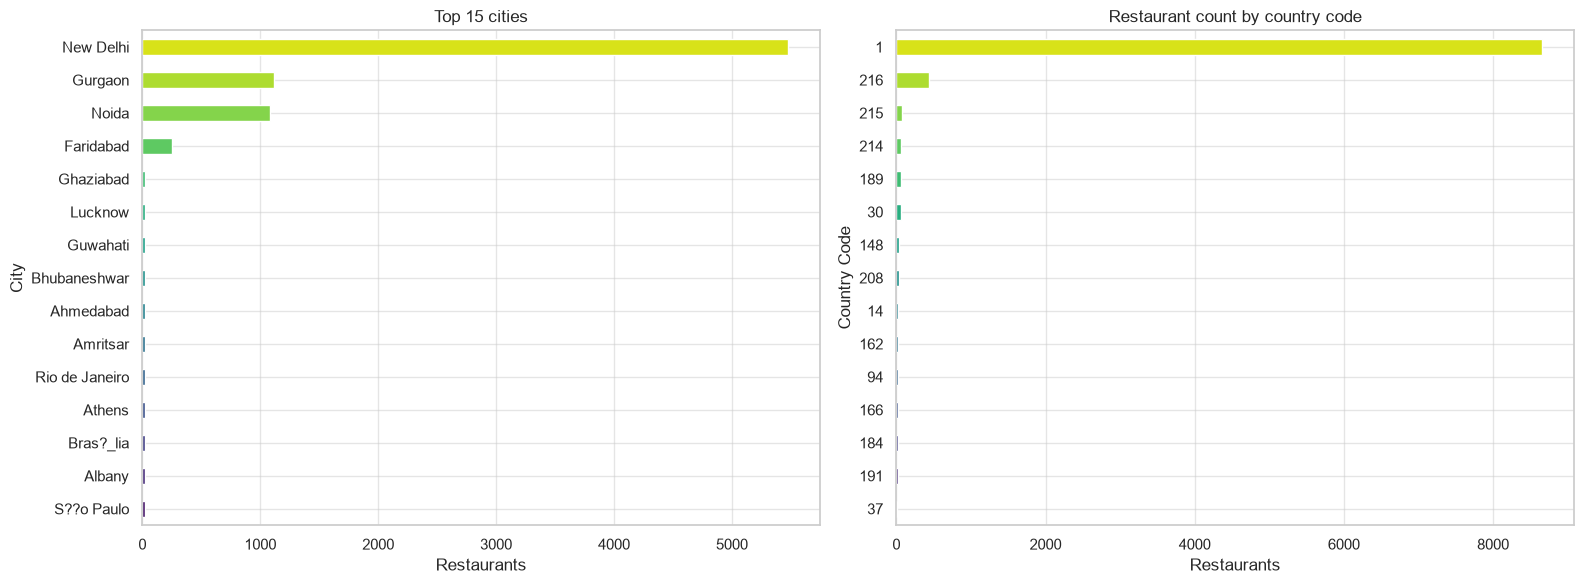

In [35]:
for col in ['Country Code', 'City']:
    if col in df.columns:
        print(f'{col}: {df[col].nunique(dropna=True)} unique values')
        display(df[col].value_counts(dropna=False).head(15).rename('restaurant_count').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title in [(axes[0], 'City', 'Top 15 cities'), (axes[1], 'Country Code', 'Restaurant count by country code')]:
    if col in df.columns:
        counts = df[col].value_counts().head(15).sort_values()
        counts.index = counts.index.map(lambda value: str(value).replace('\ufffd', '?'))
        counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(counts)))
        ax.set(title=title, xlabel='Restaurants', ylabel=col)
plt.tight_layout()
plt.show()

Unrated/zero-rating records: 2,148 (22.5%)
Mean rating including zeros: 2.67
Mean rating among rated restaurants: 3.44


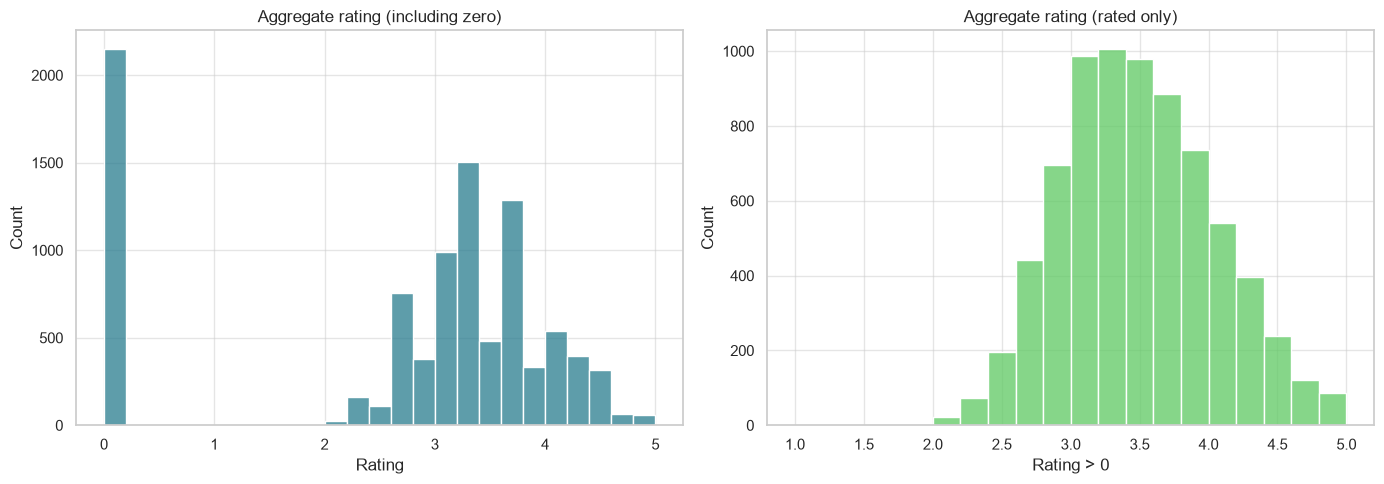

Aggregate rating,0.0,1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,3.8,3.9,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,All
Rating text,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
All,2148,1,2,7,15,27,47,87,110,191,250,315,381,468,519,522,483,498,480,458,427,400,335,266,274,221,174,144,95,78,42,25,61,9551
Average,0,0,0,0,0,0,0,0,110,191,250,315,381,468,519,522,483,498,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3737
Not rated,2148,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2148
Good,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,480,458,427,400,335,0,0,0,0,0,0,0,0,0,0,2100
Very Good,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,266,274,221,174,144,0,0,0,0,0,1079
Excellent,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,95,78,42,25,61,301
Poor,0,1,2,7,15,27,47,87,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,186


Votes summary:


,count,mean,std,min,50%,75%,90%,95%,99%,max
Votes,9551.0,156.909748,430.169145,0.0,31.0,131.0,379.0,699.0,1882.5,10934.0


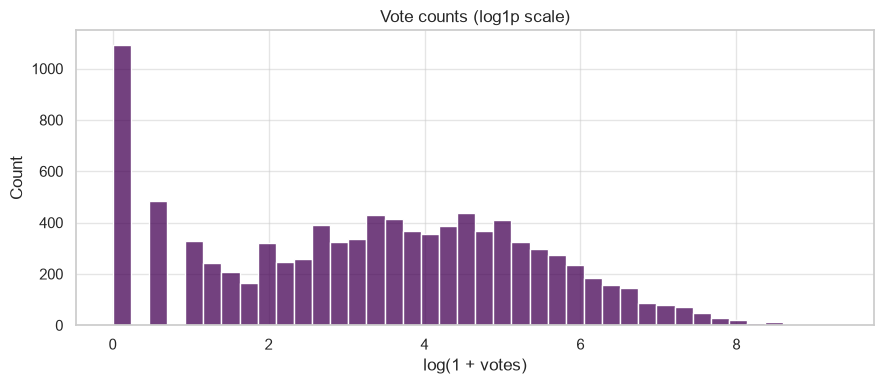

In [36]:
if 'Aggregate rating' in df.columns:
    ratings = pd.to_numeric(df['Aggregate rating'], errors='coerce')
    rated = ratings[ratings > 0]
    print(f'Unrated/zero-rating records: {(ratings == 0).sum():,} ({(ratings == 0).mean():.1%})')
    print(f'Mean rating including zeros: {ratings.mean():.2f}')
    print(f'Mean rating among rated restaurants: {rated.mean():.2f}')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(ratings.dropna(), bins=np.arange(0, 5.1, 0.2), ax=axes[0], color='#287c8e')
    axes[0].set(title='Aggregate rating (including zero)', xlabel='Rating')
    sns.histplot(rated, bins=np.arange(1, 5.1, 0.2), ax=axes[1], color='#5ec962')
    axes[1].set(title='Aggregate rating (rated only)', xlabel='Rating > 0')
    plt.tight_layout()
    plt.show()
    if 'Rating text' in df.columns:
        display(pd.crosstab(df['Rating text'], ratings, margins=True).sort_values('All', ascending=False))

if 'Votes' in df.columns:
    votes = pd.to_numeric(df['Votes'], errors='coerce')
    print('Votes summary:')
    display(votes.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame().T)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(np.log1p(votes.dropna()), bins=40, ax=ax, color='#440154')
    ax.set(title='Vote counts (log1p scale)', xlabel='log(1 + votes)')
    plt.tight_layout()
    plt.show()

,count,median,mean,min,max
Currency,,,,,
Indian Rupees(Rs.),8652,450.0,623.370319,0.0,8000.0
Dollar($),482,25.0,31.510373,0.0,500.0
Pounds(??),80,40.0,47.812500,10.0,230.0
Brazilian Real(R$),60,100.0,134.666667,30.0,400.0
Rand(R),60,340.0,419.733333,110.0,3210.0
Emirati Diram(AED),60,145.0,166.416667,40.0,500.0
NewZealand($),40,60.0,69.750000,20.0,200.0
Turkish Lira(TL),34,70.0,84.852941,30.0,400.0
Botswana Pula(P),22,1150.0,1606.818182,600.0,6000.0


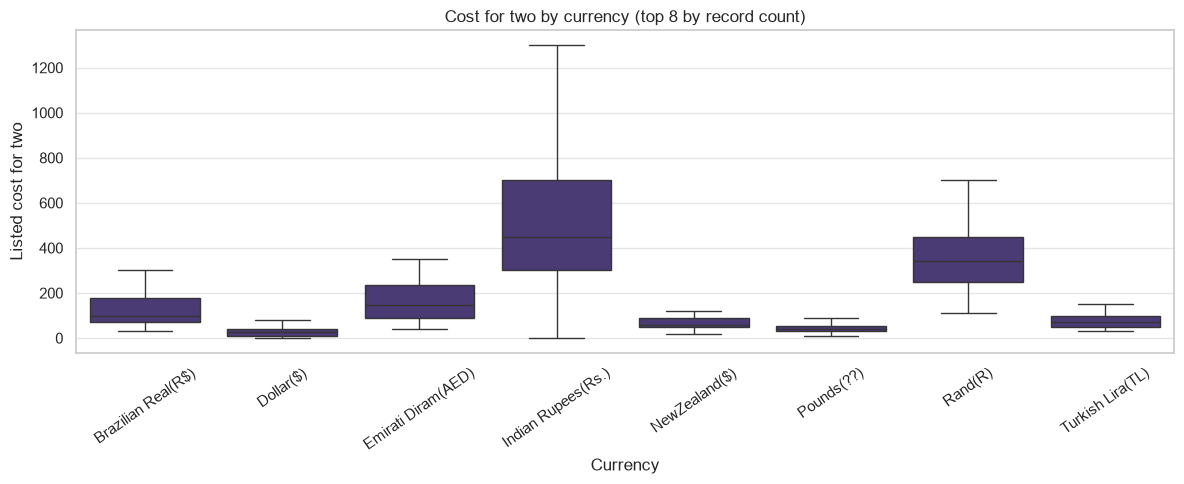

,restaurant_count
Price range,
1.0,4444
2.0,3113
3.0,1408
4.0,586


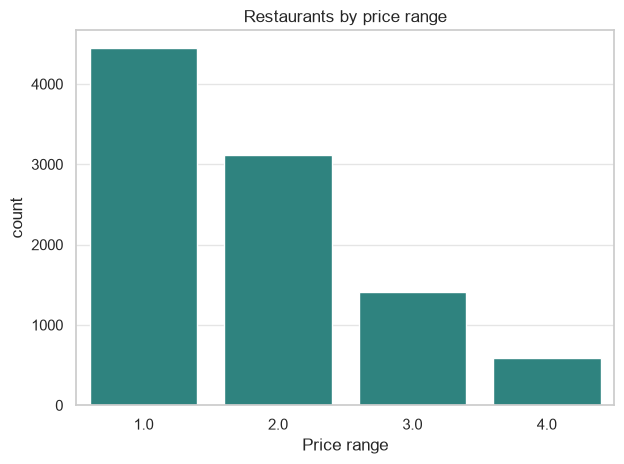

In [37]:
cost_col = 'Average Cost for two'
if cost_col in df.columns:
    df[cost_col] = pd.to_numeric(df[cost_col], errors='coerce')
    currency_col = 'Currency' if 'Currency' in df.columns else None
    if currency_col:
        currency_summary = df.groupby(currency_col)[cost_col].agg(['count', 'median', 'mean', 'min', 'max']).sort_values('count', ascending=False)
        display(currency_summary.head(15))
        top_currencies = currency_summary.head(8).index
        plot_df = df[df[currency_col].isin(top_currencies)].copy()
        # Some source labels contain undecodable characters; use a safe plot label.
        plot_df[currency_col] = plot_df[currency_col].astype(str).str.replace('\ufffd', '?', regex=False)
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.boxplot(data=plot_df, x=currency_col, y=cost_col, showfliers=False, ax=ax)
        ax.set(title='Cost for two by currency (top 8 by record count)', xlabel='Currency', ylabel='Listed cost for two')
        ax.tick_params(axis='x', rotation=35)
        plt.tight_layout()
        plt.show()
    if 'Price range' in df.columns:
        display(df['Price range'].value_counts(dropna=False).sort_index().rename('restaurant_count').to_frame())
        sns.countplot(data=df, x='Price range', color='#21918c')
        plt.title('Restaurants by price range')
        plt.tight_layout()
        plt.show()

,restaurant_appearances
Cuisines,
North Indian,3960
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


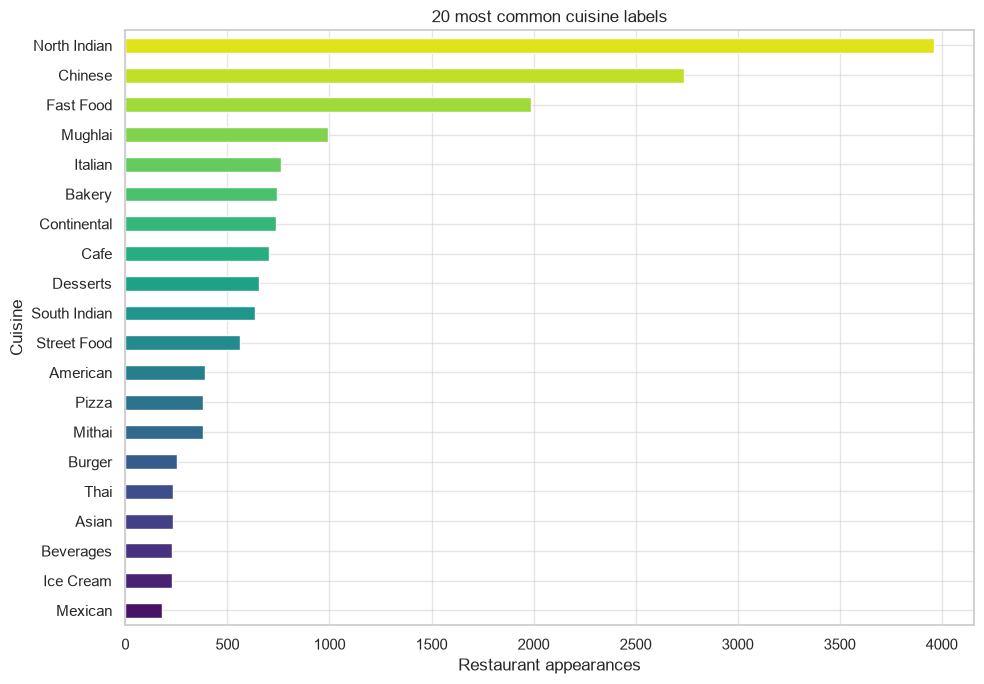

In [38]:
if 'Cuisines' in df.columns:
    cuisine_list = (df['Cuisines'].dropna().astype(str).str.split(',').explode().str.strip())
    cuisine_list = cuisine_list[cuisine_list.ne('')]
    cuisine_counts = cuisine_list.value_counts()
    display(cuisine_counts.head(20).rename('restaurant_appearances').to_frame())
    top = cuisine_counts.head(20).sort_values()
    fig, ax = plt.subplots(figsize=(10, 7))
    top.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top)))
    ax.set(title='20 most common cuisine labels', xlabel='Restaurant appearances', ylabel='Cuisine')
    plt.tight_layout()
    plt.show()

In [39]:
service_cols = [c for c in ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu'] if c in df.columns]
for col in service_cols:
    display((df[col].value_counts(dropna=False, normalize=True) * 100).round(1).rename('percent').to_frame().assign(category=lambda x: x.index).set_index('category').rename_axis(col))
if service_cols and 'Aggregate rating' in df.columns:
    rated_df = df[pd.to_numeric(df['Aggregate rating'], errors='coerce') > 0].copy()
    for col in service_cols[:2]:
        display(rated_df.groupby(col, dropna=False)['Aggregate rating'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False))

,percent
Has Table booking,
No,87.9
Yes,12.1


,percent
Has Online delivery,
No,74.3
Yes,25.7


,percent
Is delivering now,
No,99.6
Yes,0.4


,percent
Switch to order menu,
No,100.0


,count,mean,median
Has Table booking,,,
No,6292,3.413970,3.4
Yes,1111,3.587579,3.6


,count,mean,median
Has Online delivery,,,
No,5048,3.467433,3.4
Yes,2355,3.381274,3.4


,count,mean,std,min,25%,50%,75%,max
Average Cost for two,9551.0,1199.210763,16121.183073,0.000000,250.000000,400.000000,700.000000,800000.000000
Price range,9551.0,1.804837,0.905609,1.000000,1.000000,2.000000,2.000000,4.000000
Aggregate rating,9551.0,2.666370,1.516378,0.000000,2.500000,3.200000,3.700000,4.900000
Votes,9551.0,156.909748,430.169145,0.000000,5.000000,31.000000,131.000000,10934.000000
Longitude,9551.0,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.976980


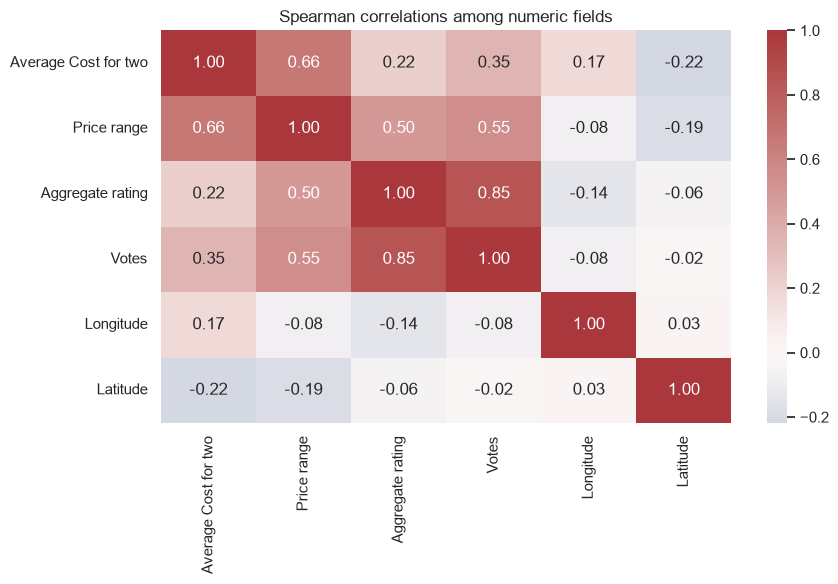

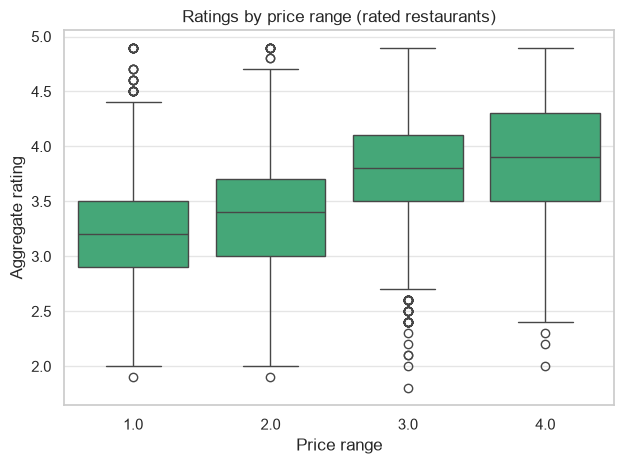

In [40]:
numeric_cols = [c for c in ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Longitude', 'Latitude'] if c in df.columns]
numeric = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
display(numeric.describe().T)
if len(numeric_cols) >= 2:
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.heatmap(numeric.corr(method='spearman'), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
    ax.set_title('Spearman correlations among numeric fields')
    plt.tight_layout()
    plt.show()
if {'Price range', 'Aggregate rating'}.issubset(df.columns):
    plot_df = df.copy()
    plot_df['Aggregate rating'] = pd.to_numeric(plot_df['Aggregate rating'], errors='coerce')
    plot_df = plot_df[plot_df['Aggregate rating'] > 0]
    sns.boxplot(data=plot_df, x='Price range', y='Aggregate rating', color='#35b779')
    plt.title('Ratings by price range (rated restaurants)')
    plt.tight_layout()
    plt.show()

Rows with both coordinates: 9,551 (100.0%)
Longitude range: -157.948486 to 174.8320893
Latitude range: -41.330428 to 55.97698


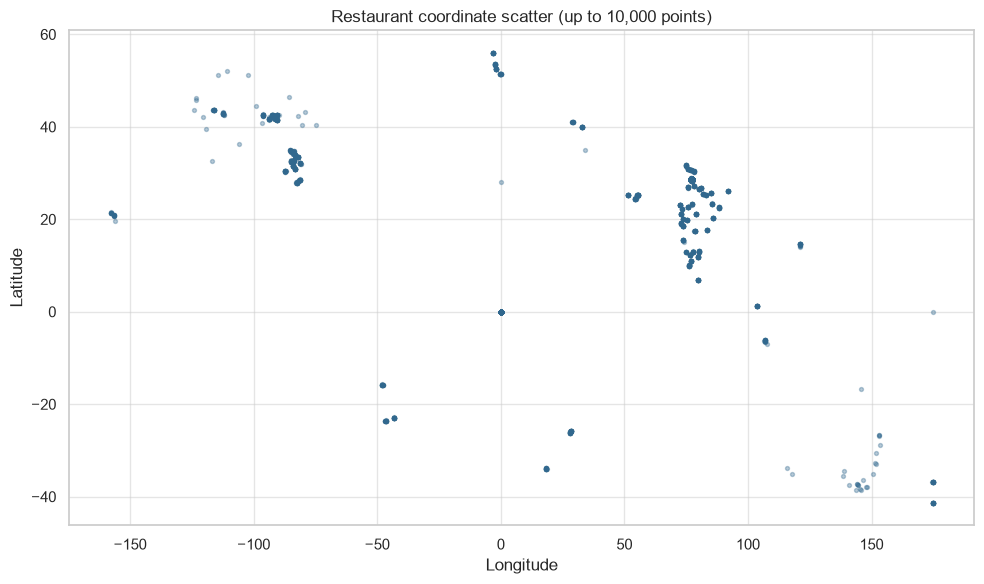

In [41]:
if {'Longitude', 'Latitude'}.issubset(df.columns):
    coords = df[['Longitude', 'Latitude']].apply(pd.to_numeric, errors='coerce')
    print(f'Rows with both coordinates: {coords.dropna().shape[0]:,} ({coords.dropna().shape[0] / len(df):.1%})')
    print('Longitude range:', coords['Longitude'].min(), 'to', coords['Longitude'].max())
    print('Latitude range:', coords['Latitude'].min(), 'to', coords['Latitude'].max())
    points = coords.dropna()
    if len(points) > 10000:
        points = points.sample(10000, random_state=42)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(points['Longitude'], points['Latitude'], s=8, alpha=.35, color='#31688e')
    ax.set(title='Restaurant coordinate scatter (up to 10,000 points)', xlabel='Longitude', ylabel='Latitude')
    plt.tight_layout()
    plt.show()

## 11. Predict restaurant ratings

This regression model estimates the aggregate rating for restaurants with a rating above zero. Zero ratings are treated as unrated records, so they are excluded from training and scored after evaluation. Rating text, rating color, votes, and restaurant ID are excluded to reduce target leakage and avoid identifiers or information that may not be available for a new restaurant. Cost is paired with currency because the dataset mixes currencies.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

TARGET = 'Aggregate rating'
FEATURES = [
    'Country Code', 'City', 'Cuisines', 'Average Cost for two', 'Currency',
    'Has Table booking', 'Has Online delivery', 'Is delivering now',
    'Price range', 'Longitude', 'Latitude',
]
FEATURES = [column for column in FEATURES if column in df.columns]

model_data = df.copy()
model_data[TARGET] = pd.to_numeric(model_data[TARGET], errors='coerce')
rated_mask = model_data[TARGET].notna() & (model_data[TARGET] > 0)
rated_data = model_data.loc[rated_mask].copy()
unrated_data = model_data.loc[~rated_mask].copy()

X = rated_data[FEATURES]
y = rated_data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = [
    column for column in [
        'Country Code', 'City', 'Cuisines', 'Currency', 'Has Table booking',
        'Has Online delivery', 'Is delivering now', 'Price range',
    ] if column in FEATURES
]
numeric_features = [column for column in FEATURES if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric_features),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10)),
        ]), categorical_features),
    ],
    remainder='drop',
)

rating_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        max_features=0.8,
        random_state=42,
        n_jobs=-1,
    )),
])
rating_model.fit(X_train, y_train)

print(f'Rated records for training/evaluation: {len(rated_data):,}')
print(f'Unrated records to score: {len(unrated_data):,}')
print(f'Features used: {FEATURES}')

Rated records for training/evaluation: 7,403
Unrated records to score: 2,148
Features used: ['Country Code', 'City', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Longitude', 'Latitude']


,MAE,RMSE,RÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â²
Model,,,
Training mean baseline,0.455,0.556,-0.000
Random Forest,0.300,0.390,0.508


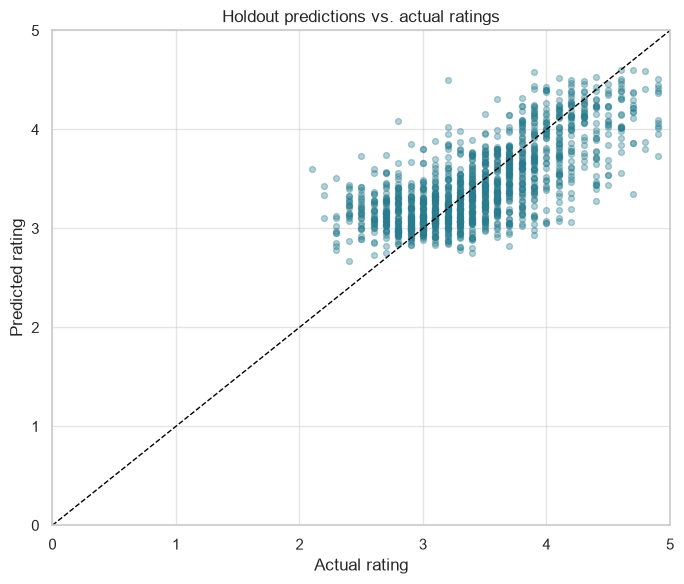

In [43]:
test_predictions = rating_model.predict(X_test)
baseline_predictions = np.full(len(y_test), y_train.mean())

evaluation = pd.DataFrame([
    {
        'Model': 'Training mean baseline',
        'MAE': mean_absolute_error(y_test, baseline_predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, baseline_predictions)),
        'RÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â²': r2_score(y_test, baseline_predictions),
    },
    {
        'Model': 'Random Forest',
        'MAE': mean_absolute_error(y_test, test_predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, test_predictions)),
        'RÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â²': r2_score(y_test, test_predictions),
    },
]).set_index('Model').round(3)
display(evaluation)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, test_predictions, alpha=0.35, s=18, color='#287c8e')
ax.plot([0, 5], [0, 5], linestyle='--', color='black', linewidth=1)
ax.set(xlim=(0, 5), ylim=(0, 5), xlabel='Actual rating', ylabel='Predicted rating',
       title='Holdout predictions vs. actual ratings')
plt.tight_layout()
plt.show()

In [44]:
final_rating_model = rating_model
final_rating_model.fit(rated_data[FEATURES], rated_data[TARGET])

if not unrated_data.empty:
    unrated_predictions = unrated_data[['Restaurant ID', 'Restaurant Name', 'City', 'Cuisines']].copy()
    unrated_predictions['Predicted rating'] = final_rating_model.predict(unrated_data[FEATURES]).round(2)
    unrated_predictions = unrated_predictions.sort_values('Predicted rating', ascending=False)
    display(unrated_predictions.head(20))
    output_path = Path('zomato_unrated_rating_predictions.csv')
    unrated_predictions.to_csv(output_path, index=False)
    print(f'Saved {len(unrated_predictions):,} predictions to: {output_path.resolve()}')
else:
    print('No unrated records were found to score.')

,Restaurant ID,Restaurant Name,City,Cuisines,Predicted rating
58,7305048,Quiosque Chopp Brahma,Rio de Janeiro,"Bar Food, Brazilian",4.47
239,17793744,Los Agaves,Davenport,Mexican,4.22
77,6701419,Divino Fog??o,S??o Paulo,"Brazilian, Mineira",4.17
69,6710645,Cantinho da Gula,S??o Paulo,Brazilian,4.16
78,6703956,Super Grill,S??o Paulo,Brazilian,4.13
238,18453427,Frick's Tap,Davenport,"American, Bar Food, BBQ",4.07
3585,18336213,Nando's,New Delhi,"Portuguese, African",3.81
9351,18273002,Damascena Coffee House,Birmingham,"Greek, Mediterranean, Middle Eastern",3.77
8206,18430587,Malt n Brew,Noida,"North Indian, Continental, Chinese",3.72
4383,18435830,Habibi Express,New Delhi,"Lebanese, Arabian, Moroccan",3.71


Saved 2,148 predictions to: C:\Users\maham\OneDrive\Desktop\Zomato ML Project\zomato_unrated_rating_predictions.csv


In [1]:
from pathlib import Path
import pandas as pd

# Load the cleaned data if this cell is run in a fresh kernel.
if 'df' not in globals():
    raw_path = Path('Zomato Restaurant Dataset.csv')
    CLEAN_DATA_PATH = Path('Zomato Restaurant Dataset Cleaned.csv')
    if CLEAN_DATA_PATH.exists():
        df = pd.read_csv(CLEAN_DATA_PATH, encoding='utf-8', encoding_errors='replace')
    elif raw_path.exists():
        df = pd.read_csv(raw_path, encoding='utf-8', encoding_errors='replace')
        CLEAN_DATA_PATH = raw_path
    else:
        raise FileNotFoundError('Could not find the cleaned or raw Zomato CSV beside the notebook.')

    exact_duplicates = 0
    duplicate_ids = 0
    missing_cuisines = 0
    if raw_path.exists():
        raw_df = pd.read_csv(raw_path, encoding='utf-8', encoding_errors='replace')
        exact_duplicates = int(raw_df.duplicated().sum())
        without_exact_duplicates = raw_df.drop_duplicates()
        if 'Restaurant ID' in without_exact_duplicates.columns:
            duplicate_ids = int(without_exact_duplicates['Restaurant ID'].duplicated().sum())
        if 'Cuisines' in raw_df.columns:
            missing_cuisines = int(raw_df['Cuisines'].isna().sum())

exact_duplicates = globals().get('exact_duplicates', 0)
duplicate_ids = globals().get('duplicate_ids', 0)
missing_cuisines = globals().get('missing_cuisines', 0)
output_path = Path('zomato_unrated_rating_predictions.csv')

total_restaurants = len(df)
zero_ratings = pd.to_numeric(df['Aggregate rating'], errors='coerce').eq(0)
rated_values = pd.to_numeric(df.loc[~zero_ratings, 'Aggregate rating'], errors='coerce').dropna()
top_cities = df['City'].value_counts().head(5)
cuisine_counts = df['Cuisines'].dropna().astype(str).str.split(',').explode().str.strip().value_counts()

print(f'Clean dataset: {total_restaurants:,} restaurants, {df.shape[1]} columns.')
print(f'Exact duplicate and duplicate restaurant IDs removed: {exact_duplicates + duplicate_ids:,}.')
print(f'Missing cuisine values filled: {missing_cuisines:,}; remaining missing cells: {int(df.isna().sum().sum()):,}.')
print(f'Unrated restaurants: {int(zero_ratings.sum()):,} ({zero_ratings.mean():.1%}); mean among rated restaurants: {rated_values.mean():.2f}.')
if not top_cities.empty:
    print(f'Top city: {top_cities.index[0]} ({top_cities.iloc[0]:,} restaurants, {top_cities.iloc[0] / total_restaurants:.1%} of records).')
if not cuisine_counts.empty:
    print(f'Most common cuisine label: {cuisine_counts.index[0]} ({cuisine_counts.iloc[0]:,} restaurant appearances).')
if 'Has Online delivery' in df.columns:
    print(f'Online delivery available: {df["Has Online delivery"].eq("Yes").mean():.1%} of restaurants.')

print()
print('Holdout model comparison:')
if 'evaluation' in globals():
    display(evaluation)
else:
    print('Model results are unavailable; run the model cells above to generate them.')

print('Output files:')
print(f' - {Path(CLEAN_DATA_PATH).resolve()}')
print(f' - {output_path.resolve()}')

Clean dataset: 9,551 restaurants, 21 columns.
Exact duplicate and duplicate restaurant IDs removed: 0.
Missing cuisine values filled: 9; remaining missing cells: 0.
Unrated restaurants: 2,148 (22.5%); mean among rated restaurants: 3.44.
Top city: New Delhi (5,473 restaurants, 57.3% of records).
Most common cuisine label: North Indian (3,960 restaurant appearances).
Online delivery available: 25.7% of restaurants.

Holdout model comparison:
Model results are unavailable; run the model cells above to generate them.
Output files:
 - C:\Users\maham\OneDrive\Desktop\Zomato ML Project\Zomato Restaurant Dataset Cleaned.csv
 - C:\Users\maham\OneDrive\Desktop\Zomato ML Project\zomato_unrated_rating_predictions.csv
